# 1. Build your own convolutional neural network using pytorch

AlexNet

In [1]:
# =========================
# Part 1: AlexNet Model
# =========================

import torch
import torch.nn as nn
from torchvision import models


class DogHeartAlexNet(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, dropout=0.5):
        super(DogHeartAlexNet, self).__init__()

        if pretrained:
            weights = models.AlexNet_Weights.IMAGENET1K_V1
            self.backbone = models.alexnet(weights=weights)
        else:
            self.backbone = models.alexnet(weights=None)

        in_features = self.backbone.classifier[6].in_features

        self.backbone.classifier[6] = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


def build_model(num_classes=3, pretrained=True):
    model = DogHeartAlexNet(
        num_classes=num_classes,
        pretrained=pretrained,
        dropout=0.5
    )
    return model

VGG-16

In [ ]:
# =========================
# Part 1: VGG-16 Model
# Domestic mirror pretrained weight version
# =========================

import os
import torch
import torch.nn as nn
from torchvision import models
from urllib.request import urlretrieve


PROJECT_DIR = r"D:\MyData\CodeProjects\CodexProjects\Homework"

PRETRAINED_DIR = os.path.join(PROJECT_DIR, "pretrained_weights")
os.makedirs(PRETRAINED_DIR, exist_ok=True)

VGG16_WEIGHT_PATH = os.path.join(PRETRAINED_DIR, "vgg16-397923af.pth")

VGG16_MIRROR_URL = "https://mirrors.tuna.tsinghua.edu.cn/pytorch/models/vgg16-397923af.pth"
VGG16_OFFICIAL_URL = "https://download.pytorch.org/models/vgg16-397923af.pth"


def download_vgg16_weight():
    if os.path.exists(VGG16_WEIGHT_PATH):
        print("Using local pretrained weight:", VGG16_WEIGHT_PATH)
        return VGG16_WEIGHT_PATH

    print("Downloading VGG16 pretrained weight from Tsinghua mirror...")
    print(VGG16_MIRROR_URL)

    try:
        urlretrieve(VGG16_MIRROR_URL, VGG16_WEIGHT_PATH)
        print("Download finished:", VGG16_WEIGHT_PATH)
    except Exception as e:
        print("Mirror download failed:", e)
        print("Trying official PyTorch url...")
        urlretrieve(VGG16_OFFICIAL_URL, VGG16_WEIGHT_PATH)
        print("Download finished:", VGG16_WEIGHT_PATH)

    return VGG16_WEIGHT_PATH


def create_vgg16_without_auto_download():
    try:
        model = models.vgg16(weights=None)
    except TypeError:
        model = models.vgg16(pretrained=False)
    return model


class DogHeartVGG16(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, dropout=0.5):
        super(DogHeartVGG16, self).__init__()

        self.backbone = create_vgg16_without_auto_download()

        if pretrained:
            weight_path = download_vgg16_weight()
            state_dict = torch.load(weight_path, map_location="cpu")
            self.backbone.load_state_dict(state_dict)
            print("Loaded ImageNet pretrained VGG16 weight.")

        in_features = self.backbone.classifier[6].in_features

        self.backbone.classifier[6] = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


def build_model(num_classes=3, pretrained=True):
    return DogHeartVGG16(
        num_classes=num_classes,
        pretrained=pretrained,
        dropout=0.5
    )

ResNet

In [10]:
# =========================
# Part 1: ResNet-50 Model
# Domestic mirror pretrained weight version
# =========================

import os
import torch
import torch.nn as nn
from torchvision import models
from urllib.request import urlretrieve


PROJECT_DIR = r"D:\MyData\CodeProjects\CodexProjects\Homework"

PRETRAINED_DIR = os.path.join(PROJECT_DIR, "pretrained_weights")
os.makedirs(PRETRAINED_DIR, exist_ok=True)

RESNET50_WEIGHT_PATH = os.path.join(PRETRAINED_DIR, "resnet50-0676ba61.pth")

RESNET50_MIRROR_URL = "https://mirrors.tuna.tsinghua.edu.cn/pytorch/models/resnet50-0676ba61.pth"
RESNET50_OFFICIAL_URL = "https://download.pytorch.org/models/resnet50-0676ba61.pth"


def download_resnet50_weight():
    if os.path.exists(RESNET50_WEIGHT_PATH):
        print("Using local pretrained weight:", RESNET50_WEIGHT_PATH)
        return RESNET50_WEIGHT_PATH

    print("Downloading ResNet-50 pretrained weight from Tsinghua mirror...")
    print(RESNET50_MIRROR_URL)

    try:
        urlretrieve(RESNET50_MIRROR_URL, RESNET50_WEIGHT_PATH)
        print("Download finished:", RESNET50_WEIGHT_PATH)
    except Exception as e:
        print("Mirror download failed:", e)
        print("Trying official PyTorch url...")
        urlretrieve(RESNET50_OFFICIAL_URL, RESNET50_WEIGHT_PATH)
        print("Download finished:", RESNET50_WEIGHT_PATH)

    return RESNET50_WEIGHT_PATH


def create_resnet50_without_auto_download():
    try:
        model = models.resnet50(weights=None)
    except TypeError:
        model = models.resnet50(pretrained=False)
    return model


class DogHeartResNet50(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, dropout=0.3):
        super(DogHeartResNet50, self).__init__()

        self.backbone = create_resnet50_without_auto_download()

        if pretrained:
            weight_path = download_resnet50_weight()
            state_dict = torch.load(weight_path, map_location="cpu")
            self.backbone.load_state_dict(state_dict)
            print("Loaded ImageNet pretrained ResNet-50 weight.")

        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


def build_model(num_classes=3, pretrained=True):
    return DogHeartResNet50(
        num_classes=num_classes,
        pretrained=pretrained,
        dropout=0.3
    )

DenseNet

In [19]:
# =========================
# Part 1: DenseNet-121 Model
# Domestic mirror + fixed key version
# =========================

import os
import re
import torch
import torch.nn as nn
from torchvision import models
from urllib.request import urlretrieve


PROJECT_DIR = r"D:\MyData\CodeProjects\CodexProjects\Homework"

PRETRAINED_DIR = os.path.join(PROJECT_DIR, "pretrained_weights")
os.makedirs(PRETRAINED_DIR, exist_ok=True)

DENSENET121_WEIGHT_PATH = os.path.join(
    PRETRAINED_DIR,
    "densenet121-a639ec97.pth"
)

DENSENET121_MIRROR_URL = "https://mirrors.tuna.tsinghua.edu.cn/pytorch/models/densenet121-a639ec97.pth"
DENSENET121_OFFICIAL_URL = "https://download.pytorch.org/models/densenet121-a639ec97.pth"


def download_densenet121_weight():
    if os.path.exists(DENSENET121_WEIGHT_PATH):
        print("Using local pretrained weight:", DENSENET121_WEIGHT_PATH)
        return DENSENET121_WEIGHT_PATH

    print("Downloading DenseNet-121 pretrained weight from Tsinghua mirror...")
    print(DENSENET121_MIRROR_URL)

    try:
        urlretrieve(DENSENET121_MIRROR_URL, DENSENET121_WEIGHT_PATH)
        print("Download finished:", DENSENET121_WEIGHT_PATH)
    except Exception as e:
        print("Mirror download failed:", e)
        print("Trying official PyTorch url...")
        urlretrieve(DENSENET121_OFFICIAL_URL, DENSENET121_WEIGHT_PATH)
        print("Download finished:", DENSENET121_WEIGHT_PATH)

    return DENSENET121_WEIGHT_PATH


def fix_densenet_state_dict_keys(state_dict):
    pattern = re.compile(
        r"^(.*denselayer\d+\.(?:norm|relu|conv))\.(\d)\.(.*)$"
    )

    new_state_dict = {}

    for key, value in state_dict.items():
        new_key = key

        match = pattern.match(key)
        if match is not None:
            new_key = match.group(1) + match.group(2) + "." + match.group(3)

        new_state_dict[new_key] = value

    return new_state_dict


def create_densenet121_without_auto_download():
    try:
        model = models.densenet121(weights=None)
    except TypeError:
        model = models.densenet121(pretrained=False)
    return model


class DogHeartDenseNet121(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, dropout=0.3):
        super(DogHeartDenseNet121, self).__init__()

        self.backbone = create_densenet121_without_auto_download()

        if pretrained:
            weight_path = download_densenet121_weight()
            state_dict = torch.load(weight_path, map_location="cpu")

            state_dict = fix_densenet_state_dict_keys(state_dict)

            load_info = self.backbone.load_state_dict(
                state_dict,
                strict=False
            )

            print("Loaded ImageNet pretrained DenseNet-121 weight.")
            print("Missing keys:", load_info.missing_keys)
            print("Unexpected keys:", load_info.unexpected_keys)

        in_features = self.backbone.classifier.in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


def build_model(num_classes=3, pretrained=True):
    return DogHeartDenseNet121(
        num_classes=num_classes,
        pretrained=pretrained,
        dropout=0.3
    )

Inception

In [1]:
# =========================
# Part 1: Inception-v3 Model
# Standard torchvision Inception-v3 for 3-class dog heart X-ray classification
# =========================

import torch
import torch.nn as nn
from torchvision import models


class DogHeartInceptionV3(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, dropout=0.4):
        super(DogHeartInceptionV3, self).__init__()

        weights = None
        if pretrained:
            try:
                weights = models.Inception_V3_Weights.IMAGENET1K_V1
            except AttributeError:
                weights = None

        try:
            self.backbone = models.inception_v3(weights=weights, aux_logits=True)
        except Exception as e:
            print("Pretrained Inception-v3 load failed, using random initialization:", e)
            try:
                self.backbone = models.inception_v3(weights=None, aux_logits=True)
            except TypeError:
                self.backbone = models.inception_v3(pretrained=False, aux_logits=True)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

        if self.backbone.AuxLogits is not None:
            aux_features = self.backbone.AuxLogits.fc.in_features
            self.backbone.AuxLogits.fc = nn.Linear(aux_features, num_classes)

    def forward(self, x):
        outputs = self.backbone(x)
        if isinstance(outputs, tuple):
            return outputs.logits
        return outputs


def build_inception_model(num_classes=3, pretrained=True):
    return DogHeartInceptionV3(
        num_classes=num_classes,
        pretrained=pretrained,
        dropout=0.4
    )


/root/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ViT

In [2]:
# =========================
# Part 1: ViT-B/16 Model
# Standard torchvision Vision Transformer for 3-class dog heart X-ray classification
# =========================

import torch
import torch.nn as nn
from torchvision import models


class DogHeartViTB16(nn.Module):
    def __init__(self, num_classes=3, pretrained=True, dropout=0.2):
        super(DogHeartViTB16, self).__init__()

        weights = None
        if pretrained:
            try:
                weights = models.ViT_B_16_Weights.IMAGENET1K_V1
            except AttributeError:
                weights = None

        try:
            self.backbone = models.vit_b_16(weights=weights)
        except Exception as e:
            print("Pretrained ViT-B/16 load failed, using random initialization:", e)
            try:
                self.backbone = models.vit_b_16(weights=None)
            except TypeError:
                self.backbone = models.vit_b_16(pretrained=False)

        in_features = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


def build_vit_model(num_classes=3, pretrained=True):
    return DogHeartViTB16(
        num_classes=num_classes,
        pretrained=pretrained,
        dropout=0.2
    )


个人创作

In [1]:
# =========================
# V20260615_01
# Single-model innovation: DogHeartProjectViT
# One model only: project-local ViT-B/16 checkpoint initialization + conservative fine-tuning.
# No ensemble, no CSV fusion, no test-label use, no network access, no external cache dependency.
# =========================

import os
import torch
import torch.nn as nn
from torchvision import models

MYSELF_VERSION = "V20260615_01"
PROJECT_VIT_CKPT = os.path.join("vit_b16_outputs", "best_vit_b16_dogheart.pth")


class DogHeartProjectViT(nn.Module):
    def __init__(self, num_classes=3, dropout=0.24, pretrained=False):
        super().__init__()
        try:
            self.backbone = models.vit_b_16(weights=None)
        except TypeError:
            self.backbone = models.vit_b_16(pretrained=False)
        in_features = self.backbone.heads.head.in_features
        self.backbone.heads.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.backbone(x)


def build_myself_model(num_classes=3, pretrained=False, dropout=0.24, **kwargs):
    return DogHeartProjectViT(num_classes=num_classes, dropout=dropout, pretrained=pretrained)


def project_vit_checkpoint_path(project_dir=None):
    project_dir = project_dir or os.getcwd()
    candidates = [os.path.join(project_dir, PROJECT_VIT_CKPT)]
    if not os.path.exists(os.path.join(project_dir, "Dog_Heart")):
        candidates.append(os.path.join("/gemini/code/Homework", PROJECT_VIT_CKPT))
    for path in candidates:
        if os.path.exists(path):
            return path
    return None

/root/miniconda3/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Train your model using cow teat datasets (you may need to use  Google Colab (or Kaggle) with GPU to train your code) 

### (1) use torchvision.datasets.ImageFolder for the training dataset
### (2) use custom dataloader for test dataset (return image tensor and file name)

训练

AlexNet

In [3]:
# =========================
# Part 2: Train AlexNet
# use torchvision.datasets.ImageFolder
# =========================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm


# -------------------------
# Basic Config
# -------------------------

PROJECT_DIR = r"D:\Homework"
DATA_DIR = os.path.join(PROJECT_DIR, "Dog_Heart")

TRAIN_DIR = os.path.join(DATA_DIR, "Train")
VALID_DIR = os.path.join(DATA_DIR, "Valid")

SAVE_DIR = os.path.join(PROJECT_DIR, "alexnet_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_alexnet_dogheart.pth")

NUM_CLASSES = 3
BATCH_SIZE = 32
EPOCHS = 40
LR = 1e-4
WEIGHT_DECAY = 1e-4
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# -------------------------
# Reproducibility
# -------------------------

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


set_seed(SEED)


# -------------------------
# Transforms
# -------------------------

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.08
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# -------------------------
# Dataset
# Requirement:
# use torchvision.datasets.ImageFolder for training dataset
# -------------------------

train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root=VALID_DIR,
    transform=valid_transform
)

print("Class to idx:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))

# 强制确认标签顺序
assert train_dataset.class_to_idx == {'Large': 0, 'Normal': 1, 'Small': 2}


# -------------------------
# Class Weight
# -------------------------

targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(targets, minlength=NUM_CLASSES)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class counts:", class_counts)
print("Class weights:", class_weights)


# -------------------------
# DataLoader
# Windows/Jupyter 建议 num_workers=0
# -------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# -------------------------
# Model
# -------------------------

model = build_model(
    num_classes=NUM_CLASSES,
    pretrained=True
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)


# -------------------------
# Train / Validate
# -------------------------

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Training"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


best_valid_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion
    )

    scheduler.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_dataset.class_to_idx,
            "class_names": train_dataset.classes,
            "best_valid_acc": best_valid_acc,
            "epoch": epoch
        }

        torch.save(checkpoint, BEST_MODEL_PATH)

        print("Best model saved:", BEST_MODEL_PATH)
        print("Best valid acc:", best_valid_acc)

print("\nTraining finished.")
print("Best valid acc:", best_valid_acc)
print("Best model path:", BEST_MODEL_PATH)

Device: cuda
Class to idx: {'Large': 0, 'Normal': 1, 'Small': 2}
Train size: 1400
Valid size: 200
Class counts: [619 573 208]
Class weights: tensor([0.5933, 0.6410, 1.7657], device='cuda:0')
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\Lenovo/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [02:13<00:00, 1.82MB/s] 



Epoch [1/40]


Validation: 100%|██████████| 7/7 [00:03<00:00,  1.90it/s]


Train Loss: 0.8796 | Train Acc: 0.4957
Valid Loss: 0.8090 | Valid Acc: 0.5900
Best model saved: D:\Homework\alexnet_outputs\best_alexnet_dogheart.pth
Best valid acc: 0.59

Epoch [2/40]


...

Train Loss: 0.2018 | Train Acc: 0.8921
Valid Loss: 0.6574 | Valid Acc: 0.7200

Epoch [39/40]


Validation: 100%|██████████| 7/7 [00:03<00:00,  2.28it/s]


Train Loss: 0.2117 | Train Acc: 0.8886
Valid Loss: 0.6659 | Valid Acc: 0.7200

Epoch [40/40]


Validation: 100%|██████████| 7/7 [00:02<00:00,  2.40it/s]

Train Loss: 0.1959 | Train Acc: 0.9071
Valid Loss: 0.6579 | Valid Acc: 0.7200

Training finished.
Best valid acc: 0.75
Best model path: D:\Homework\alexnet_outputs\best_alexnet_dogheart.pth


VGG-16

In [8]:
# =========================
# Part 2: Train VGG-16
# Requirement:
# use torchvision.datasets.ImageFolder for the training dataset
# =========================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm


PROJECT_DIR = r"D:\Homework"
DATA_DIR = os.path.join(PROJECT_DIR, "Dog_Heart")

TRAIN_DIR = os.path.join(DATA_DIR, "Train")
VALID_DIR = os.path.join(DATA_DIR, "Valid")

SAVE_DIR = os.path.join(PROJECT_DIR, "vgg16_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_vgg16_dogheart.pth")

NUM_CLASSES = 3
BATCH_SIZE = 16
EPOCHS = 35
LR = 1e-4
WEIGHT_DECAY = 1e-4
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


set_seed(SEED)


train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.08
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root=VALID_DIR,
    transform=valid_transform
)

print("Class to idx:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))

assert train_dataset.class_to_idx == {'Large': 0, 'Normal': 1, 'Small': 2}


targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(targets, minlength=NUM_CLASSES)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class counts:", class_counts)
print("Class weights:", class_weights)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


model = build_model(
    num_classes=NUM_CLASSES,
    pretrained=True
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Training"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


best_valid_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion
    )

    scheduler.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_dataset.class_to_idx,
            "class_names": train_dataset.classes,
            "best_valid_acc": best_valid_acc,
            "epoch": epoch
        }

        torch.save(checkpoint, BEST_MODEL_PATH)

        print("Best model saved:", BEST_MODEL_PATH)
        print("Best valid acc:", best_valid_acc)


print("\nTraining finished.")
print("Best valid acc:", best_valid_acc)
print("Best model path:", BEST_MODEL_PATH)

Device: cuda
Class to idx: {'Large': 0, 'Normal': 1, 'Small': 2}
Train size: 1400
Valid size: 200
Class counts: [619 573 208]
Class weights: tensor([0.5933, 0.6410, 1.7657], device='cuda:0')
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Lenovo/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [04:44<00:00, 1.95MB/s]  



Epoch [1/35]


Validation: 100%|██████████| 13/13 [00:03<00:00,  4.28it/s]


Train Loss: 1.1020 | Train Acc: 0.4064
Valid Loss: 1.0595 | Valid Acc: 0.3800
Best model saved: D:\Homework\vgg16_outputs\best_vgg16_dogheart.pth
Best valid acc: 0.38

Epoch [2/35]


...

Train Loss: 0.0839 | Train Acc: 0.9593
Valid Loss: 0.9426 | Valid Acc: 0.7400

Epoch [34/35]


Validation: 100%|██████████| 13/13 [00:03<00:00,  3.89it/s]


Train Loss: 0.0972 | Train Acc: 0.9543
Valid Loss: 0.9469 | Valid Acc: 0.7450

Epoch [35/35]


Validation: 100%|██████████| 13/13 [00:03<00:00,  3.95it/s]

Train Loss: 0.0734 | Train Acc: 0.9729
Valid Loss: 0.9364 | Valid Acc: 0.7400

Training finished.
Best valid acc: 0.75
Best model path: D:\Homework\vgg16_outputs\best_vgg16_dogheart.pth


ResNet

In [13]:
# =========================
# Part 2: Train ResNet-50
# Requirement:
# use torchvision.datasets.ImageFolder for the training dataset
# =========================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm


PROJECT_DIR = r"D:\Homework"
DATA_DIR = os.path.join(PROJECT_DIR, "Dog_Heart")

TRAIN_DIR = os.path.join(DATA_DIR, "Train")
VALID_DIR = os.path.join(DATA_DIR, "Valid")

SAVE_DIR = os.path.join(PROJECT_DIR, "resnet50_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_resnet50_dogheart.pth")

NUM_CLASSES = 3
BATCH_SIZE = 24
EPOCHS = 35
LR = 1e-4
WEIGHT_DECAY = 1e-4
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


set_seed(SEED)


train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.08
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root=VALID_DIR,
    transform=valid_transform
)

print("Class to idx:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))

assert train_dataset.class_to_idx == {'Large': 0, 'Normal': 1, 'Small': 2}


targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(targets, minlength=NUM_CLASSES)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class counts:", class_counts)
print("Class weights:", class_weights)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


model = build_model(
    num_classes=NUM_CLASSES,
    pretrained=True
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Training"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


best_valid_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion
    )

    scheduler.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_dataset.class_to_idx,
            "class_names": train_dataset.classes,
            "best_valid_acc": best_valid_acc,
            "epoch": epoch
        }

        torch.save(checkpoint, BEST_MODEL_PATH)

        print("Best model saved:", BEST_MODEL_PATH)
        print("Best valid acc:", best_valid_acc)


print("\nTraining finished.")
print("Best valid acc:", best_valid_acc)
print("Best model path:", BEST_MODEL_PATH)

Device: cuda
Class to idx: {'Large': 0, 'Normal': 1, 'Small': 2}
Train size: 1400
Valid size: 200
Class counts: [619 573 208]
Class weights: tensor([0.5933, 0.6410, 1.7657], device='cuda:0')
https://mirrors.tuna.tsinghua.edu.cn/pytorch/models/resnet50-0676ba61.pth
Mirror download failed: HTTP Error 404: Not Found
Trying official PyTorch url...
Download finished: D:\Homework\pretrained_weights\resnet50-0676ba61.pth
Loaded ImageNet pretrained ResNet-50 weight.

Epoch [1/35]


Validation: 100%|██████████| 9/9 [00:02<00:00,  3.60it/s]


Train Loss: 0.9025 | Train Acc: 0.5043
Valid Loss: 0.9466 | Valid Acc: 0.6200
Best model saved: D:\Homework\resnet50_outputs\best_resnet50_dogheart.pth
Best valid acc: 0.62

Epoch [2/35]


Validation: 100%|██████████| 9/9 [00:02<00:00,  3.60it/s]


Train Loss: 0.7385 | Train Acc: 0.6429
Valid Loss: 0.9088 | Valid Acc: 0.6950
Best model saved: D:\Homework\resnet50_outputs\best_resnet50_dogheart.pth
Best valid acc: 0.695

Epoch [3/35]


...

Train Loss: 0.0436 | Train Acc: 0.9857
Valid Loss: 0.7961 | Valid Acc: 0.7750

Epoch [34/35]


Validation: 100%|██████████| 9/9 [00:03<00:00,  2.94it/s]


Train Loss: 0.0436 | Train Acc: 0.9850
Valid Loss: 0.7708 | Valid Acc: 0.7850

Epoch [35/35]


Validation: 100%|██████████| 9/9 [00:03<00:00,  2.88it/s]

Train Loss: 0.0428 | Train Acc: 0.9821
Valid Loss: 0.8428 | Valid Acc: 0.7800

Training finished.
Best valid acc: 0.805
Best model path: D:\Homework\resnet50_outputs\best_resnet50_dogheart.pth


DenseNet

In [20]:
# =========================
# Part 2: Train DenseNet-121
# Requirement:
# use torchvision.datasets.ImageFolder for the training dataset
# =========================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from tqdm import tqdm


PROJECT_DIR = r"D:\Homework"
DATA_DIR = os.path.join(PROJECT_DIR, "Dog_Heart")

TRAIN_DIR = os.path.join(DATA_DIR, "Train")
VALID_DIR = os.path.join(DATA_DIR, "Valid")

SAVE_DIR = os.path.join(PROJECT_DIR, "densenet121_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_densenet121_dogheart.pth")

NUM_CLASSES = 3
BATCH_SIZE = 24
EPOCHS = 35
LR = 1e-4
WEIGHT_DECAY = 1e-4
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


set_seed(SEED)


train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.08
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root=VALID_DIR,
    transform=valid_transform
)

print("Class to idx:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))

assert train_dataset.class_to_idx == {'Large': 0, 'Normal': 1, 'Small': 2}


targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(targets, minlength=NUM_CLASSES)

class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print("Class counts:", class_counts)
print("Class weights:", class_weights)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


model = build_model(
    num_classes=NUM_CLASSES,
    pretrained=True
).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Training"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def validate_one_epoch(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation"):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


best_valid_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    valid_loss, valid_acc = validate_one_epoch(
        model,
        valid_loader,
        criterion
    )

    scheduler.step()

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")

    if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_dataset.class_to_idx,
            "class_names": train_dataset.classes,
            "best_valid_acc": best_valid_acc,
            "epoch": epoch
        }

        torch.save(checkpoint, BEST_MODEL_PATH)

        print("Best model saved:", BEST_MODEL_PATH)
        print("Best valid acc:", best_valid_acc)


print("\nTraining finished.")
print("Best valid acc:", best_valid_acc)
print("Best model path:", BEST_MODEL_PATH)

Device: cuda
Class to idx: {'Large': 0, 'Normal': 1, 'Small': 2}
Train size: 1400
Valid size: 200
Class counts: [619 573 208]
Class weights: tensor([0.5933, 0.6410, 1.7657], device='cuda:0')
Using local pretrained weight: D:\MyData\CodeProjects\CodexProjects\Homework\pretrained_weights\densenet121-a639ec97.pth
Loaded ImageNet pretrained DenseNet-121 weight.
Missing keys: []
Unexpected keys: []

Epoch [1/35]


Validation: 100%|██████████| 9/9 [00:02<00:00,  3.59it/s]


Train Loss: 0.9181 | Train Acc: 0.4571
Valid Loss: 0.9744 | Valid Acc: 0.5400
Best model saved: D:\Homework\densenet121_outputs\best_densenet121_dogheart.pth
Best valid acc: 0.54

Epoch [2/35]


Validation: 100%|██████████| 9/9 [00:02<00:00,  3.44it/s]


Train Loss: 0.7437 | Train Acc: 0.5929
Valid Loss: 0.8508 | Valid Acc: 0.6250
Best model saved: D:\Homework\densenet121_outputs\best_densenet121_dogheart.pth
Best valid acc: 0.625

Epoch [3/35]


...

Train Loss: 0.0622 | Train Acc: 0.9793
Valid Loss: 0.8477 | Valid Acc: 0.7750

Epoch [34/35]


Validation: 100%|██████████| 9/9 [00:03<00:00,  2.92it/s]


Train Loss: 0.0705 | Train Acc: 0.9757
Valid Loss: 0.8233 | Valid Acc: 0.7800
Best model saved: D:\Homework\densenet121_outputs\best_densenet121_dogheart.pth
Best valid acc: 0.78

Epoch [35/35]


Validation: 100%|██████████| 9/9 [00:03<00:00,  2.88it/s]

Train Loss: 0.0548 | Train Acc: 0.9800
Valid Loss: 0.8291 | Valid Acc: 0.7750

Training finished.
Best valid acc: 0.78
Best model path: D:\Homework\densenet121_outputs\best_densenet121_dogheart.pth


Inception

In [3]:
# =========================
# Part 2: Train Inception-v3
# use torchvision.datasets.ImageFolder for Train and Valid
# =========================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm import tqdm


PROJECT_DIR = os.getcwd()
if not os.path.exists(os.path.join(PROJECT_DIR, "Dog_Heart")):
    PROJECT_DIR = "/gemini/code/Homework"

DATA_DIR = os.path.join(PROJECT_DIR, "Dog_Heart")
TRAIN_DIR = os.path.join(DATA_DIR, "Train")
VALID_DIR = os.path.join(DATA_DIR, "Valid")

SAVE_DIR = os.path.join(PROJECT_DIR, "inception_v3_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_inception_v3_dogheart.pth")

NUM_CLASSES = 3
IMAGE_SIZE = 299
BATCH_SIZE = 16
EPOCHS = 35
LR = 8e-5
WEIGHT_DECAY = 1e-4
SEED = 42
NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


set_seed(SEED)


train_transform = transforms.Compose([
    transforms.Resize((342, 342)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.80, 1.0), ratio=(0.90, 1.10)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.08, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((342, 342)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
valid_dataset = datasets.ImageFolder(VALID_DIR, transform=valid_transform)

print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))

targets = np.array(train_dataset.targets)
class_counts = np.bincount(targets, minlength=NUM_CLASSES)
class_weights_np = class_counts.sum() / np.maximum(class_counts, 1)
sample_weights = class_weights_np[targets]
sampler = WeightedRandomSampler(
    weights=sample_weights.tolist(),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


model = build_inception_model(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)

class_weights = torch.tensor(
    class_weights_np / class_weights_np.mean(),
    dtype=torch.float32,
    device=DEVICE
)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.03)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Training"):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Validation"):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds


best_valid_score = -1.0
best_valid_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    valid_loss, valid_acc, valid_f1, valid_labels, valid_preds = validate_one_epoch(
        model,
        valid_loader,
        criterion
    )

    scheduler.step()
    valid_score = valid_acc + 0.15 * valid_f1

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f} | Valid F1: {valid_f1:.4f} | Score: {valid_score:.4f}")

    if valid_score > best_valid_score:
        best_valid_score = valid_score
        best_valid_acc = valid_acc

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_dataset.class_to_idx,
            "class_names": train_dataset.classes,
            "best_valid_acc": best_valid_acc,
            "best_valid_f1": valid_f1,
            "best_valid_score": best_valid_score,
            "epoch": epoch,
            "image_size": IMAGE_SIZE,
            "model_name": "Inception-v3"
        }

        torch.save(checkpoint, BEST_MODEL_PATH)
        print("Best model saved:", BEST_MODEL_PATH)
        print("Best valid acc:", best_valid_acc)
        print("Confusion matrix:")
        print(confusion_matrix(valid_labels, valid_preds))


print("\nTraining finished.")
print("Best valid acc:", best_valid_acc)
print("Best valid score:", best_valid_score)
print("Best model path:", BEST_MODEL_PATH)


Device: cuda
Classes: ['Large', 'Normal', 'Small']
Class to index: {'Large': 0, 'Normal': 1, 'Small': 2}
Train size: 1400
Valid size: 200


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [00:49<00:00, 2.22MB/s] 



Epoch [1/35]


Validation: 100%|██████████| 13/13 [00:02<00:00,  5.73it/s]


Train Loss: 0.6270 | Train Acc: 0.6021 | Train F1: 0.5812
Valid Loss: 0.9142 | Valid Acc: 0.6400 | Valid F1: 0.6548 | Score: 0.7382
Best model saved: /gemini/code/Homework/inception_v3_outputs/best_inception_v3_dogheart.pth
Best valid acc: 0.64
Confusion matrix:
[[32 41  3]
 [14 64 13]
 [ 0  1 32]]

Epoch [2/35]


...

Train Loss: 0.1331 | Train Acc: 0.9900 | Train F1: 0.9900
Valid Loss: 1.0195 | Valid Acc: 0.7350 | Valid F1: 0.7663 | Score: 0.8499

Epoch [34/35]


Validation: 100%|██████████| 13/13 [00:02<00:00,  6.12it/s]


Train Loss: 0.1351 | Train Acc: 0.9886 | Train F1: 0.9888
Valid Loss: 1.0368 | Valid Acc: 0.7400 | Valid F1: 0.7701 | Score: 0.8555

Epoch [35/35]


Validation: 100%|██████████| 13/13 [00:02<00:00,  5.91it/s]

Train Loss: 0.1311 | Train Acc: 0.9879 | Train F1: 0.9881
Valid Loss: 1.0033 | Valid Acc: 0.7600 | Valid F1: 0.7844 | Score: 0.8777

Training finished.
Best valid acc: 0.77
Best valid score: 0.890117790706026
Best model path: /gemini/code/Homework/inception_v3_outputs/best_inception_v3_dogheart.pth


ViT

In [4]:
# =========================
# Part 2: Train ViT-B/16
# use torchvision.datasets.ImageFolder for Train and Valid
# =========================

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm import tqdm


PROJECT_DIR = os.getcwd()
if not os.path.exists(os.path.join(PROJECT_DIR, "Dog_Heart")):
    PROJECT_DIR = "/gemini/code/Homework"

DATA_DIR = os.path.join(PROJECT_DIR, "Dog_Heart")
TRAIN_DIR = os.path.join(DATA_DIR, "Train")
VALID_DIR = os.path.join(DATA_DIR, "Valid")

SAVE_DIR = os.path.join(PROJECT_DIR, "vit_b16_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_vit_b16_dogheart.pth")

NUM_CLASSES = 3
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
LR = 5e-5
WEIGHT_DECAY = 1e-4
SEED = 42
NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


set_seed(SEED)


train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.80, 1.0), ratio=(0.90, 1.10)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.08, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
valid_dataset = datasets.ImageFolder(VALID_DIR, transform=valid_transform)

print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))

targets = np.array(train_dataset.targets)
class_counts = np.bincount(targets, minlength=NUM_CLASSES)
class_weights_np = class_counts.sum() / np.maximum(class_counts, 1)
sample_weights = class_weights_np[targets]
sampler = WeightedRandomSampler(
    weights=sample_weights.tolist(),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


model = build_vit_model(num_classes=NUM_CLASSES, pretrained=True).to(DEVICE)

class_weights = torch.tensor(
    class_weights_np / class_weights_np.mean(),
    dtype=torch.float32,
    device=DEVICE
)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.03)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Training"):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 3.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Validation"):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds


best_valid_score = -1.0
best_valid_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{EPOCHS}]")

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    valid_loss, valid_acc, valid_f1, valid_labels, valid_preds = validate_one_epoch(
        model,
        valid_loader,
        criterion
    )

    scheduler.step()
    valid_score = valid_acc + 0.15 * valid_f1

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f} | Valid F1: {valid_f1:.4f} | Score: {valid_score:.4f}")

    if valid_score > best_valid_score:
        best_valid_score = valid_score
        best_valid_acc = valid_acc

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_dataset.class_to_idx,
            "class_names": train_dataset.classes,
            "best_valid_acc": best_valid_acc,
            "best_valid_f1": valid_f1,
            "best_valid_score": best_valid_score,
            "epoch": epoch,
            "image_size": IMAGE_SIZE,
            "model_name": "ViT-B/16"
        }

        torch.save(checkpoint, BEST_MODEL_PATH)
        print("Best model saved:", BEST_MODEL_PATH)
        print("Best valid acc:", best_valid_acc)
        print("Confusion matrix:")
        print(confusion_matrix(valid_labels, valid_preds))


print("\nTraining finished.")
print("Best valid acc:", best_valid_acc)
print("Best valid score:", best_valid_score)
print("Best model path:", BEST_MODEL_PATH)


Device: cuda
Classes: ['Large', 'Normal', 'Small']
Class to index: {'Large': 0, 'Normal': 1, 'Small': 2}
Train size: 1400
Valid size: 200


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [01:49<00:00, 3.16MB/s] 



Epoch [1/30]


Validation: 100%|██████████| 13/13 [00:02<00:00,  4.81it/s]


Train Loss: 0.6176 | Train Acc: 0.6243 | Train F1: 0.6117
Valid Loss: 0.8271 | Valid Acc: 0.6300 | Valid F1: 0.6585 | Score: 0.7288
Best model saved: /gemini/code/Homework/vit_b16_outputs/best_vit_b16_dogheart.pth
Best valid acc: 0.63
Confusion matrix:
[[36 39  1]
 [21 58 12]
 [ 0  1 32]]

Epoch [2/30]


...

Train Loss: 0.1146 | Train Acc: 0.9943 | Train F1: 0.9942
Valid Loss: 0.8948 | Valid Acc: 0.7800 | Valid F1: 0.7949 | Score: 0.8992

Epoch [29/30]


Validation: 100%|██████████| 13/13 [00:02<00:00,  5.05it/s]


Train Loss: 0.1245 | Train Acc: 0.9914 | Train F1: 0.9914
Valid Loss: 0.8787 | Valid Acc: 0.7800 | Valid F1: 0.7949 | Score: 0.8992

Epoch [30/30]


Validation: 100%|██████████| 13/13 [00:02<00:00,  4.96it/s]

Train Loss: 0.1218 | Train Acc: 0.9914 | Train F1: 0.9913
Valid Loss: 0.8772 | Valid Acc: 0.7800 | Valid F1: 0.7949 | Score: 0.8992

Training finished.
Best valid acc: 0.795
Best valid score: 0.916920051701581
Best model path: /gemini/code/Homework/vit_b16_outputs/best_vit_b16_dogheart.pth


个人创作

In [2]:
# =========================
# V20260615_01 COMPLETE TRAINING
# Single ProjectViT model only. Initialize from project-local ViT checkpoint, then light fine-tune.
# No ensemble, no CSV fusion, no old checkpoint skip.
# =========================

import os
import random
import time
import json
import copy
import numpy as np
import torch
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm import tqdm

print("Notebook version:", MYSELF_VERSION)

PROJECT_DIR = os.getcwd()
if not os.path.exists(os.path.join(PROJECT_DIR, "Dog_Heart")):
    PROJECT_DIR = "/gemini/code/Homework"

DATA_DIR = os.path.join(PROJECT_DIR, "Dog_Heart")
TRAIN_DIR = os.path.join(DATA_DIR, "Train")
VALID_DIR = os.path.join(DATA_DIR, "Valid")
SAVE_DIR = os.path.join(PROJECT_DIR, "myself_create_outputs")
os.makedirs(SAVE_DIR, exist_ok=True)

NUM_CLASSES = 3
IMAGE_SIZE = 224
RESIZE_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 16
PATIENCE = 5
NUM_WORKERS = 0
LR_BACKBONE = 1.4e-5
LR_HEAD = 5.0e-5
WEIGHT_DECAY = 8e-5
SEED = 2026061406
DROPOUT = 0.24
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_STAMP = "projectvit_v20260615_01_" + time.strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(SAVE_DIR, RUN_STAMP)
os.makedirs(RUN_DIR, exist_ok=True)
BEST_PATH = os.path.join(RUN_DIR, "best_dogheart_projectvit_v20260615_01.pth")
MANIFEST_PATH = os.path.join(RUN_DIR, "manifest.txt")
LATEST_MANIFEST_PATH = os.path.join(SAVE_DIR, "latest_manifest.txt")

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Run dir:", RUN_DIR)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


class ModelEMA:
    def __init__(self, model, decay=0.996):
        self.ema = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        source = model.state_dict()
        for key, value in self.ema.state_dict().items():
            src = source[key].detach()
            if value.dtype.is_floating_point:
                value.copy_(value * self.decay + src * (1.0 - self.decay))
            else:
                value.copy_(src)


class SmoothFocalCE(torch.nn.Module):
    def __init__(self, weight=None, gamma=0.55, smoothing=0.025):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.smoothing = smoothing

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight, reduction="none", label_smoothing=self.smoothing)
        pt = torch.exp(-ce).clamp(1e-4, 1.0)
        return (((1.0 - pt) ** self.gamma) * ce).mean()


def metric_score(labels, preds):
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return acc + 0.15 * f1, acc, f1


set_seed(SEED)
train_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.82, 1.0), ratio=(0.90, 1.10)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(7),
    transforms.ColorJitter(brightness=0.06, contrast=0.12),
    transforms.RandomAutocontrast(p=0.18),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
valid_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, train_transform)
valid_ds = datasets.ImageFolder(VALID_DIR, valid_transform)
print("Classes:", train_ds.classes, train_ds.class_to_idx)
print("Train size:", len(train_ds), "Valid size:", len(valid_ds))
counts = np.bincount(train_ds.targets, minlength=NUM_CLASSES)
weights_np = counts.sum() / np.maximum(counts, 1)
loss_weights = torch.tensor(weights_np / weights_np.mean(), dtype=torch.float32, device=DEVICE)
sample_weights = np.sqrt(weights_np[train_ds.targets])
generator = torch.Generator().manual_seed(SEED)
sampler = WeightedRandomSampler(sample_weights.tolist(), len(sample_weights), replacement=True, generator=generator)
print("Class counts:", counts.tolist(), "Loss weights:", loss_weights.detach().cpu().numpy().round(3).tolist())

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

model = build_myself_model(NUM_CLASSES, pretrained=False, dropout=DROPOUT).to(DEVICE)
init_ckpt_path = project_vit_checkpoint_path(PROJECT_DIR)
if init_ckpt_path is None:
    print("Project ViT checkpoint not found; training ProjectViT from random initialization.")
else:
    ckpt = torch.load(init_ckpt_path, map_location=DEVICE, weights_only=False)
    missing, unexpected = model.load_state_dict(ckpt["model_state_dict"], strict=False)
    print("Initialized from project ViT checkpoint:", init_ckpt_path)
    print("Source epoch:", ckpt.get("epoch"), "valid acc:", ckpt.get("best_valid_acc"), "valid f1:", ckpt.get("best_valid_f1"))
    print("Missing keys:", len(missing), "Unexpected keys:", len(unexpected))

ema = ModelEMA(model, decay=0.996)
criterion = SmoothFocalCE(loss_weights)
head_params = list(model.backbone.heads.parameters())
head_param_ids = {id(p) for p in head_params}
backbone_params = [p for p in model.parameters() if id(p) not in head_param_ids]
optimizer = optim.AdamW([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": head_params, "lr": LR_HEAD},
], weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


def train_epoch(epoch):
    model.train()
    loss_sum, preds, labs = 0.0, [], []
    for x, y in tqdm(train_loader, desc=f"{MYSELF_VERSION} epoch {epoch:02d}"):
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)
        loss_sum += loss.item() * y.size(0)
        preds += logits.argmax(1).detach().cpu().tolist()
        labs += y.detach().cpu().tolist()
    _, acc, f1 = metric_score(labs, preds)
    return loss_sum / len(train_ds), acc, f1


@torch.no_grad()
def valid_epoch(eval_model):
    eval_model.eval()
    loss_sum, logits_list, labs = 0.0, [], []
    for x, y in tqdm(valid_loader, desc="valid"):
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        logits = eval_model(x)
        loss = criterion(logits, y)
        loss_sum += loss.item() * y.size(0)
        logits_list.append(logits.detach().cpu())
        labs += y.detach().cpu().tolist()
    logits = torch.cat(logits_list, dim=0)
    preds = logits.argmax(1).numpy().tolist()
    score, acc, f1 = metric_score(labs, preds)
    return loss_sum / len(valid_ds), score, acc, f1, labs, preds

best_score, best_epoch, stale = -1.0, 0, 0
history = []
start = time.time()
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = train_epoch(epoch)
    scheduler.step()
    raw_loss, raw_score, raw_acc, raw_f1, raw_labs, raw_preds = valid_epoch(model)
    ema_loss, ema_score, ema_acc, ema_f1, ema_labs, ema_preds = valid_epoch(ema.ema)
    if ema_score >= raw_score:
        va_loss, va_score, va_acc, va_f1, labs, preds, save_state, weight_source = ema_loss, ema_score, ema_acc, ema_f1, ema_labs, ema_preds, ema.ema.state_dict(), "ema"
    else:
        va_loss, va_score, va_acc, va_f1, labs, preds, save_state, weight_source = raw_loss, raw_score, raw_acc, raw_f1, raw_labs, raw_preds, model.state_dict(), "raw"
    row = {"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc, "train_f1": tr_f1, "raw_score": raw_score, "ema_score": ema_score, "valid_loss": va_loss, "valid_score": va_score, "valid_acc": va_acc, "valid_f1": va_f1, "weight_source": weight_source, "cm": confusion_matrix(labs, preds).tolist()}
    history.append(row)
    print(f"Epoch {epoch:02d}: train loss {tr_loss:.4f} acc {tr_acc:.4f} f1 {tr_f1:.4f} | raw {raw_score:.4f} ema {ema_score:.4f} | selected {weight_source} acc {va_acc:.4f} f1 {va_f1:.4f} score {va_score:.4f}")
    print("CM:", row["cm"])
    if va_score > best_score + 1e-6:
        best_score, best_epoch, stale = va_score, epoch, 0
        torch.save({
            "version": MYSELF_VERSION,
            "model_name": "DogHeartProjectViT",
            "model_state_dict": save_state,
            "class_names": train_ds.classes,
            "class_to_idx": train_ds.class_to_idx,
            "image_size": IMAGE_SIZE,
            "resize_size": RESIZE_SIZE,
            "valid_acc": va_acc,
            "valid_macro_f1": va_f1,
            "best_valid_score": best_score,
            "epoch": epoch,
            "seed": SEED,
            "dropout": DROPOUT,
            "weight_source": weight_source,
            "init_checkpoint": init_ckpt_path,
            "history": history,
        }, BEST_PATH)
        print("Saved best:", BEST_PATH)
    else:
        stale += 1
        if epoch >= 6 and stale >= PATIENCE:
            print("Early stopping at epoch", epoch, "best epoch", best_epoch)
            break

with open(os.path.join(RUN_DIR, "history.json"), "w", encoding="utf-8") as f:
    json.dump(history, f, ensure_ascii=False, indent=2)
with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    f.write(f"{BEST_PATH}\t{best_score:.6f}\n")
with open(LATEST_MANIFEST_PATH, "w", encoding="utf-8") as f:
    f.write(f"{BEST_PATH}\t{best_score:.6f}\n")
print("Training finished.")
print("Best epoch:", best_epoch, "Best valid score:", round(best_score, 6))
print("Manifest:", MANIFEST_PATH)
print("Latest manifest:", LATEST_MANIFEST_PATH)
print("Training minutes:", round((time.time() - start) / 60, 2))

Notebook version: V20260615_01
Device: cuda
GPU: NVIDIA H20-3e
Run dir: /gemini/code/Homework/myself_create_outputs/projectvit_v20260615_01_20260615_095432
Classes: ['Large', 'Normal', 'Small'] {'Large': 0, 'Normal': 1, 'Small': 2}
Train size: 1400 Valid size: 200
Class counts: [619, 573, 208] Loss weights: [0.5929999947547913, 0.640999972820282, 1.7660000324249268]
Initialized from project ViT checkpoint: /gemini/code/Homework/vit_b16_outputs/best_vit_b16_dogheart.pth
Source epoch: 13 valid acc: 0.795 valid f1: 0.8128003446772066
Missing keys: 0 Unexpected keys: 0


valid: 100%|██████████| 13/13 [00:39<00:00,  3.02s/it]


Epoch 01: train loss 0.0908 acc 0.9436 f1 0.9502 | raw 0.8335 ema 0.9169 | selected ema acc 0.7950 f1 0.8128 score 0.9169
CM: [[61, 15, 0], [18, 67, 6], [0, 2, 31]]
Saved best: /gemini/code/Homework/myself_create_outputs/projectvit_v20260615_01_20260615_095432/best_dogheart_projectvit_v20260615_01.pth


valid: 100%|██████████| 13/13 [00:35<00:00,  2.73s/it]


Epoch 02: train loss 0.0882 acc 0.9421 f1 0.9483 | raw 0.8754 ema 0.9113 | selected ema acc 0.7900 f1 0.8086 score 0.9113
CM: [[61, 15, 0], [19, 67, 5], [0, 3, 30]]


...

Epoch 04: train loss 0.0649 acc 0.9621 f1 0.9656 | raw 0.8820 ema 0.8880 | selected ema acc 0.7700 f1 0.7869 score 0.8880
CM: [[61, 15, 0], [21, 64, 6], [0, 4, 29]]


valid: 100%|██████████| 13/13 [00:34<00:00,  2.65s/it]


Epoch 05: train loss 0.0632 acc 0.9686 f1 0.9716 | raw 0.8824 ema 0.8595 | selected raw acc 0.7650 f1 0.7824 score 0.8824
CM: [[59, 17, 0], [20, 66, 5], [0, 5, 28]]


valid: 100%|██████████| 13/13 [00:35<00:00,  2.77s/it]

Epoch 06: train loss 0.0658 acc 0.9650 f1 0.9689 | raw 0.9108 ema 0.8764 | selected raw acc 0.7900 f1 0.8056 score 0.9108
CM: [[60, 16, 0], [17, 69, 5], [0, 4, 29]]
Early stopping at epoch 6 best epoch 1
Training finished.
Best epoch: 1 Best valid score: 0.916926
Manifest: /gemini/code/Homework/myself_create_outputs/projectvit_v20260615_01_20260615_095432/manifest.txt
Latest manifest: /gemini/code/Homework/myself_create_outputs/latest_manifest.txt
Training minutes: 33.9


预测

AlexNet

In [4]:
# =========================
# Part 3: Predict AlexNet
# use custom dataloader for test dataset
# return image tensor and file name
# =========================

import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm


# -------------------------
# Basic Config
# -------------------------

PROJECT_DIR = r"D:\Homework"

TEST_DIR = os.path.join(PROJECT_DIR, "Dog_Heart", "Test", "Images")
SAVE_DIR = os.path.join(PROJECT_DIR, "alexnet_outputs")

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_alexnet_dogheart.pth")
PRED_CSV_PATH = os.path.join(PROJECT_DIR, "prediction_submit_alexnet.csv")

NUM_CLASSES = 3
BATCH_SIZE = 32

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# -------------------------
# Test Transform
# -------------------------

test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# -------------------------
# Custom Test Dataset
# Requirement:
# custom dataloader returns image tensor and file name
# -------------------------

class DogHeartTestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        image_exts = [".jpg", ".jpeg", ".png", ".bmp"]

        self.image_files = [
            f for f in os.listdir(image_dir)
            if os.path.splitext(f)[1].lower() in image_exts
        ]

        self.image_files = sorted(self.image_files)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        file_name = self.image_files[idx]
        image_path = os.path.join(self.image_dir, file_name)

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, file_name


test_dataset = DogHeartTestDataset(
    image_dir=TEST_DIR,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test images:", len(test_dataset))


# -------------------------
# Load Model
# -------------------------

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

class_to_idx = checkpoint["class_to_idx"]
class_names = checkpoint["class_names"]

print("Class names:", class_names)
print("Class to idx:", class_to_idx)

model = build_model(
    num_classes=NUM_CLASSES,
    pretrained=False
).to(DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()


# -------------------------
# Predict
# CSV format:
# filename,label
# no header, no index
# -------------------------

results = []

with torch.no_grad():
    for images, file_names in tqdm(test_loader, desc="Predicting"):
        images = images.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        preds = preds.detach().cpu().numpy()

        for file_name, pred_label in zip(file_names, preds):
            results.append([file_name, int(pred_label)])


result_df = pd.DataFrame(results)

result_df.to_csv(
    PRED_CSV_PATH,
    index=False,
    header=False,
    encoding="utf-8"
)

print("Prediction csv saved to:", PRED_CSV_PATH)
print(result_df.head())
print("Total predictions:", len(result_df))

Device: cuda
Test images: 400
Class names: ['Large', 'Normal', 'Small']
Class to idx: {'Large': 0, 'Normal': 1, 'Small': 2}


Predicting: 100%|██████████| 13/13 [00:07<00:00,  1.75it/s]

Prediction csv saved to: D:\Homework\prediction_submit_alexnet.csv
          0  1
0   100.png  1
1  1621.png  1
2  1622.png  2
3  1623.png  2
4  1624.png  2
Total predictions: 400


VGG-16

In [9]:
# =========================
# Part 3: Predict VGG-16
# Requirement:
# use custom dataloader for test dataset
# return image tensor and file name
# =========================

import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm


PROJECT_DIR = r"D:\Homework"

TEST_DIR = os.path.join(PROJECT_DIR, "Dog_Heart", "Test", "Images")
SAVE_DIR = os.path.join(PROJECT_DIR, "vgg16_outputs")

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_vgg16_dogheart.pth")
PRED_CSV_PATH = os.path.join(PROJECT_DIR, "prediction_submit_vgg16.csv")

NUM_CLASSES = 3
BATCH_SIZE = 16

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class DogHeartTestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        image_exts = [".jpg", ".jpeg", ".png", ".bmp"]

        self.image_files = [
            f for f in os.listdir(image_dir)
            if os.path.splitext(f)[1].lower() in image_exts
        ]

        self.image_files = sorted(self.image_files)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        file_name = self.image_files[idx]
        image_path = os.path.join(self.image_dir, file_name)

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, file_name


test_dataset = DogHeartTestDataset(
    image_dir=TEST_DIR,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test images:", len(test_dataset))


checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

print("Class names:", checkpoint["class_names"])
print("Class to idx:", checkpoint["class_to_idx"])

model = build_model(
    num_classes=NUM_CLASSES,
    pretrained=False
).to(DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()


results = []

with torch.no_grad():
    for images, file_names in tqdm(test_loader, desc="Predicting"):
        images = images.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        preds = preds.detach().cpu().numpy()

        for file_name, pred_label in zip(file_names, preds):
            results.append([file_name, int(pred_label)])


result_df = pd.DataFrame(results)

result_df.to_csv(
    PRED_CSV_PATH,
    index=False,
    header=False,
    encoding="utf-8"
)

print("Prediction csv saved to:", PRED_CSV_PATH)
print(result_df.head())
print("Total predictions:", len(result_df))

Device: cuda
Test images: 400
Class names: ['Large', 'Normal', 'Small']
Class to idx: {'Large': 0, 'Normal': 1, 'Small': 2}


Predicting: 100%|██████████| 25/25 [00:06<00:00,  3.65it/s]

Prediction csv saved to: D:\Homework\prediction_submit_vgg16.csv
          0  1
0   100.png  0
1  1621.png  0
2  1622.png  2
3  1623.png  2
4  1624.png  2
Total predictions: 400


ResNet

In [15]:
# =========================
# Part 3: Predict ResNet-50
# Requirement:
# use custom dataloader for test dataset
# return image tensor and file name
# =========================

import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm


PROJECT_DIR = r"D:\Homework"

TEST_DIR = os.path.join(PROJECT_DIR, "Dog_Heart", "Test", "Images")
SAVE_DIR = os.path.join(PROJECT_DIR, "resnet50_outputs")

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_resnet50_dogheart.pth")
PRED_CSV_PATH = os.path.join(PROJECT_DIR, "prediction_submit_resnet50.csv")

NUM_CLASSES = 3
BATCH_SIZE = 24

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class DogHeartTestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        image_exts = [".jpg", ".jpeg", ".png", ".bmp"]

        self.image_files = [
            f for f in os.listdir(image_dir)
            if os.path.splitext(f)[1].lower() in image_exts
        ]

        self.image_files = sorted(self.image_files)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        file_name = self.image_files[idx]
        image_path = os.path.join(self.image_dir, file_name)

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, file_name


test_dataset = DogHeartTestDataset(
    image_dir=TEST_DIR,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test images:", len(test_dataset))


checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

print("Class names:", checkpoint["class_names"])
print("Class to idx:", checkpoint["class_to_idx"])

model = build_model(
    num_classes=NUM_CLASSES,
    pretrained=False
).to(DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()


results = []

with torch.no_grad():
    for images, file_names in tqdm(test_loader, desc="Predicting"):
        images = images.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        preds = preds.detach().cpu().numpy()

        for file_name, pred_label in zip(file_names, preds):
            results.append([file_name, int(pred_label)])


result_df = pd.DataFrame(results)

result_df.to_csv(
    PRED_CSV_PATH,
    index=False,
    header=False,
    encoding="utf-8"
)

print("Prediction csv saved to:", PRED_CSV_PATH)
print(result_df.head())
print("Total predictions:", len(result_df))

Device: cuda
Test images: 400
Class names: ['Large', 'Normal', 'Small']
Class to idx: {'Large': 0, 'Normal': 1, 'Small': 2}


Predicting: 100%|██████████| 17/17 [00:05<00:00,  3.03it/s]

Prediction csv saved to: D:\Homework\prediction_submit_resnet50.csv
          0  1
0   100.png  0
1  1621.png  0
2  1622.png  2
3  1623.png  2
4  1624.png  2
Total predictions: 400


DenseNet

In [21]:
# =========================
# Part 3: Predict DenseNet-121
# Requirement:
# use custom dataloader for test dataset
# return image tensor and file name
# =========================

import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm


PROJECT_DIR = r"D:\Homework"

TEST_DIR = os.path.join(PROJECT_DIR, "Dog_Heart", "Test", "Images")
SAVE_DIR = os.path.join(PROJECT_DIR, "densenet121_outputs")

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_densenet121_dogheart.pth")
PRED_CSV_PATH = os.path.join(PROJECT_DIR, "prediction_submit_densenet121.csv")

NUM_CLASSES = 3
BATCH_SIZE = 24

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class DogHeartTestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        image_exts = [".jpg", ".jpeg", ".png", ".bmp"]

        self.image_files = [
            f for f in os.listdir(image_dir)
            if os.path.splitext(f)[1].lower() in image_exts
        ]

        self.image_files = sorted(self.image_files)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        file_name = self.image_files[idx]
        image_path = os.path.join(self.image_dir, file_name)

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, file_name


test_dataset = DogHeartTestDataset(
    image_dir=TEST_DIR,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test images:", len(test_dataset))


checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

print("Class names:", checkpoint["class_names"])
print("Class to idx:", checkpoint["class_to_idx"])

model = build_model(
    num_classes=NUM_CLASSES,
    pretrained=False
).to(DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()


results = []

with torch.no_grad():
    for images, file_names in tqdm(test_loader, desc="Predicting"):
        images = images.to(DEVICE)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        preds = preds.detach().cpu().numpy()

        for file_name, pred_label in zip(file_names, preds):
            results.append([file_name, int(pred_label)])


result_df = pd.DataFrame(results)

result_df.to_csv(
    PRED_CSV_PATH,
    index=False,
    header=False,
    encoding="utf-8"
)

print("Prediction csv saved to:", PRED_CSV_PATH)
print(result_df.head())
print("Total predictions:", len(result_df))

Device: cuda
Test images: 400
Class names: ['Large', 'Normal', 'Small']
Class to idx: {'Large': 0, 'Normal': 1, 'Small': 2}


Predicting: 100%|██████████| 17/17 [00:06<00:00,  2.70it/s]

Prediction csv saved to: D:\Homework\prediction_submit_densenet121.csv
          0  1
0   100.png  1
1  1621.png  0
2  1622.png  2
3  1623.png  2
4  1624.png  2
Total predictions: 400


Inception

In [5]:
# =========================
# Part 3: Predict Inception-v3
# custom dataloader returns image tensor and file name
# output csv: filename,label
# =========================

import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm


PROJECT_DIR = os.getcwd()
if not os.path.exists(os.path.join(PROJECT_DIR, "Dog_Heart")):
    PROJECT_DIR = "/gemini/code/Homework"

TEST_DIR = os.path.join(PROJECT_DIR, "Dog_Heart", "Test", "Images")
SAVE_DIR = os.path.join(PROJECT_DIR, "inception_v3_outputs")

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_inception_v3_dogheart.pth")
PRED_CSV_PATH = os.path.join(PROJECT_DIR, "prediction_submit_inception_v3.csv")

NUM_CLASSES = 3
IMAGE_SIZE = 299
BATCH_SIZE = 16
NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


test_transform = transforms.Compose([
    transforms.Resize((342, 342)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class DogHeartTestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        image_exts = [".jpg", ".jpeg", ".png", ".bmp"]
        self.image_files = [
            f for f in os.listdir(image_dir)
            if os.path.splitext(f)[1].lower() in image_exts
        ]
        self.image_files = sorted(self.image_files)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        file_name = self.image_files[idx]
        image_path = os.path.join(self.image_dir, file_name)
        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, file_name


test_dataset = DogHeartTestDataset(TEST_DIR, transform=test_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Test size:", len(test_dataset))


model = build_inception_model(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded model:", BEST_MODEL_PATH)
print("Checkpoint epoch:", checkpoint.get("epoch", "unknown"))
print("Checkpoint valid acc:", checkpoint.get("best_valid_acc", "unknown"))


all_file_names = []
all_preds = []

with torch.no_grad():
    for images, file_names in tqdm(test_loader, desc="Predicting"):
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_file_names.extend(list(file_names))
        all_preds.extend(preds.detach().cpu().numpy().tolist())


submission = pd.DataFrame({
    "filename": all_file_names,
    "label": all_preds
})

submission.to_csv(PRED_CSV_PATH, index=False, header=False)

print("Prediction csv saved:", PRED_CSV_PATH)
print(submission.head())
print(submission["label"].value_counts().sort_index())


Device: cuda
Test size: 400


/root/miniconda3/lib/python3.11/site-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


Loaded model: /gemini/code/Homework/inception_v3_outputs/best_inception_v3_dogheart.pth
Checkpoint epoch: 19
Checkpoint valid acc: 0.77


Predicting: 100%|██████████| 25/25 [00:08<00:00,  2.93it/s]

Prediction csv saved: /gemini/code/Homework/prediction_submit_inception_v3.csv
   filename  label
0   100.png      0
1  1621.png      0
2  1622.png      2
3  1623.png      2
4  1624.png      2
label
0    189
1    154
2     57
Name: count, dtype: int64


ViT

In [6]:
# =========================
# Part 3: Predict ViT-B/16
# custom dataloader returns image tensor and file name
# output csv: filename,label
# =========================

import os
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm


PROJECT_DIR = os.getcwd()
if not os.path.exists(os.path.join(PROJECT_DIR, "Dog_Heart")):
    PROJECT_DIR = "/gemini/code/Homework"

TEST_DIR = os.path.join(PROJECT_DIR, "Dog_Heart", "Test", "Images")
SAVE_DIR = os.path.join(PROJECT_DIR, "vit_b16_outputs")

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "best_vit_b16_dogheart.pth")
PRED_CSV_PATH = os.path.join(PROJECT_DIR, "prediction_submit_vit_b16.csv")

NUM_CLASSES = 3
IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class DogHeartTestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        image_exts = [".jpg", ".jpeg", ".png", ".bmp"]
        self.image_files = [
            f for f in os.listdir(image_dir)
            if os.path.splitext(f)[1].lower() in image_exts
        ]
        self.image_files = sorted(self.image_files)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        file_name = self.image_files[idx]
        image_path = os.path.join(self.image_dir, file_name)
        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, file_name


test_dataset = DogHeartTestDataset(TEST_DIR, transform=test_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Test size:", len(test_dataset))


model = build_vit_model(num_classes=NUM_CLASSES, pretrained=False).to(DEVICE)
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded model:", BEST_MODEL_PATH)
print("Checkpoint epoch:", checkpoint.get("epoch", "unknown"))
print("Checkpoint valid acc:", checkpoint.get("best_valid_acc", "unknown"))


all_file_names = []
all_preds = []

with torch.no_grad():
    for images, file_names in tqdm(test_loader, desc="Predicting"):
        images = images.to(DEVICE, non_blocking=True)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_file_names.extend(list(file_names))
        all_preds.extend(preds.detach().cpu().numpy().tolist())


submission = pd.DataFrame({
    "filename": all_file_names,
    "label": all_preds
})

submission.to_csv(PRED_CSV_PATH, index=False, header=False)

print("Prediction csv saved:", PRED_CSV_PATH)
print(submission.head())
print(submission["label"].value_counts().sort_index())


Device: cuda
Test size: 400
Loaded model: /gemini/code/Homework/vit_b16_outputs/best_vit_b16_dogheart.pth
Checkpoint epoch: 13
Checkpoint valid acc: 0.795


Predicting: 100%|██████████| 25/25 [00:07<00:00,  3.14it/s]

Prediction csv saved: /gemini/code/Homework/prediction_submit_vit_b16.csv
   filename  label
0   100.png      0
1  1621.png      0
2  1622.png      2
3  1623.png      2
4  1624.png      2
label
0    159
1    173
2     68
Name: count, dtype: int64


个人创作

In [ ]:
# =========================
# V20260615_01 PREDICT
# Single newly trained ProjectViT checkpoint only.
# Valid selects center-crop scale set and calibration; Test uses the same transform.
# No ensemble, no CSV fusion, no test-label use.
# Output csv: filename,numeric_label; no header
# =========================

import os
import itertools
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

print("Notebook version:", MYSELF_VERSION)

PROJECT_DIR = os.getcwd()
if not os.path.exists(os.path.join(PROJECT_DIR, "Dog_Heart")):
    PROJECT_DIR = "/gemini/code/Homework"

DATA_DIR = os.path.join(PROJECT_DIR, "Dog_Heart")
VALID_DIR = os.path.join(DATA_DIR, "Valid")
TEST_DIR = os.path.join(DATA_DIR, "Test", "Images")
SAVE_DIR = os.path.join(PROJECT_DIR, "myself_create_outputs")
LATEST_MANIFEST_PATH = os.path.join(SAVE_DIR, "latest_manifest.txt")
PRED_CSV_PATH = os.path.join(PROJECT_DIR, "prediction_submit_myself_create_v20260615_01_recommended.csv")
PRED_ALIAS_PATH = os.path.join(PROJECT_DIR, "prediction_submit_myself_create_strong.csv")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 24
NUM_WORKERS = 0
NUM_CLASSES = 3
print("Device:", DEVICE)


class DogHeartTestDataset(Dataset):
    def __init__(self, image_dir, transform):
        self.image_dir = image_dir
        self.transform = transform
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        file_name = self.image_files[idx]
        image = Image.open(os.path.join(self.image_dir, file_name)).convert("RGB")
        return self.transform(image), file_name


def make_transform(resize_size, crop_size=224):
    return transforms.Compose([
        transforms.Resize((resize_size, resize_size)),
        transforms.CenterCrop(crop_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])


def load_latest_checkpoint_path():
    if not os.path.exists(LATEST_MANIFEST_PATH):
        raise FileNotFoundError("latest_manifest.txt not found. Run the V20260615_01 training cell first.")
    with open(LATEST_MANIFEST_PATH, "r", encoding="utf-8") as f:
        path = f.readline().strip().split("\t")[0]
    if not path or not os.path.exists(path):
        raise FileNotFoundError("Checkpoint in latest_manifest.txt does not exist: " + str(path))
    return path


@torch.no_grad()
def predict_loader(model, loader, desc):
    probs_list, names = [], []
    model.eval()
    for batch in tqdm(loader, desc=desc):
        images = batch[0].to(DEVICE, non_blocking=True)
        logits = model(images)
        probs_list.append(torch.softmax(logits, dim=1).detach().cpu())
        if len(batch) > 1 and isinstance(batch[1], (list, tuple)):
            names.extend(list(batch[1]))
    return torch.cat(probs_list, dim=0), names


def predict_dataset_tta(model, dataset_factory, resize_list, crop_size, desc_prefix):
    all_probs, all_names = None, None
    for resize in resize_list:
        dataset = dataset_factory(make_transform(resize, crop_size))
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
        probs, names = predict_loader(model, loader, f"{desc_prefix} resize {resize}")
        if all_probs is None:
            all_probs, all_names = probs, names
        else:
            if names and all_names != names:
                raise RuntimeError("Image order changed between prediction passes")
            all_probs += probs
    return all_probs / len(resize_list), all_names


def metric_score(labels, preds):
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return acc + 0.15 * f1, acc, f1


def find_best_valid_calibration(valid_probs, valid_labels):
    base_logits = torch.log(valid_probs.clamp_min(1e-6))
    labels_np = torch.tensor(valid_labels, dtype=torch.long).numpy()
    base_preds = base_logits.argmax(1).numpy()
    base_score, base_acc, base_f1 = metric_score(labels_np, base_preds)
    records = []
    bias_grid = [x / 100.0 for x in range(-25, 26, 5)]
    temp_grid = [0.90, 0.98, 1.00, 1.08, 1.18]
    for temp, large_bias, small_bias in itertools.product(temp_grid, bias_grid, bias_grid):
        bias = torch.tensor([large_bias, 0.0, small_bias], dtype=base_logits.dtype)
        preds = (base_logits / temp + bias).argmax(1).numpy()
        score, acc, f1 = metric_score(labels_np, preds)
        objective = acc + 0.04 * f1 - 0.012 * (abs(large_bias) + abs(small_bias))
        records.append((objective, score, acc, f1, temp, bias))
    records.sort(key=lambda x: x[0], reverse=True)
    top = records[:8]
    weights = torch.softmax(torch.tensor([r[0] for r in top]) * 20.0, dim=0)
    avg_temp = float(sum(float(w) * r[4] for w, r in zip(weights, top)))
    avg_bias = sum(float(w) * r[5] for w, r in zip(weights, top)) * 0.80
    avg_temp = 1.0 + 0.80 * (avg_temp - 1.0)
    final_preds = (base_logits / avg_temp + avg_bias).argmax(1).numpy()
    final_score, final_acc, final_f1 = metric_score(labels_np, final_preds)
    if final_acc < base_acc:
        avg_temp = 1.0
        avg_bias = torch.zeros(3, dtype=base_logits.dtype)
        final_score, final_acc, final_f1 = base_score, base_acc, base_f1
    return base_score, base_acc, base_f1, final_score, final_acc, final_f1, avg_temp, avg_bias


ckpt_path = load_latest_checkpoint_path()
checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
if checkpoint.get("version") != MYSELF_VERSION:
    print("Warning: checkpoint version is", checkpoint.get("version"), "but notebook is", MYSELF_VERSION)
print("Loaded checkpoint:", ckpt_path)
print("Best valid acc:", checkpoint.get("valid_acc"), "valid f1:", checkpoint.get("valid_macro_f1"), "epoch:", checkpoint.get("epoch"), "source:", checkpoint.get("weight_source"))

crop_size = int(checkpoint.get("image_size", 224))
model = build_myself_model(NUM_CLASSES, pretrained=False, dropout=float(checkpoint.get("dropout", 0.24))).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"], strict=True)
model.eval()

valid_labels = datasets.ImageFolder(VALID_DIR, transform=make_transform(256, crop_size)).targets
scale_sets = [
    [256],
    [240, 256, 272],
    [232, 248, 264, 280],
    [224, 240, 256, 272, 288],
]
best_pack = None
for resize_list in scale_sets:
    valid_probs, _ = predict_dataset_tta(model, lambda tf: datasets.ImageFolder(VALID_DIR, transform=tf), resize_list, crop_size, "valid")
    pack = find_best_valid_calibration(valid_probs, valid_labels)
    base_score, base_acc, base_f1, final_score, final_acc, final_f1, final_temp, final_bias = pack
    print("Scale set", resize_list, "base acc/f1", round(base_acc, 4), round(base_f1, 4), "final acc/f1", round(final_acc, 4), round(final_f1, 4), "temp", round(final_temp, 3), "bias", final_bias.tolist())
    objective = final_acc + 0.02 * final_f1 - 0.002 * len(resize_list)
    if best_pack is None or objective > best_pack[0]:
        best_pack = (objective, resize_list, final_temp, final_bias, final_acc, final_f1)

_, resize_list, final_temp, final_bias, final_acc, final_f1 = best_pack
print("Selected scale set:", resize_list, "valid acc/f1:", round(final_acc, 4), round(final_f1, 4), "temp:", round(final_temp, 3), "bias:", final_bias.tolist())

test_probs, test_names = predict_dataset_tta(model, lambda tf: DogHeartTestDataset(TEST_DIR, tf), resize_list, crop_size, "test")
test_logits = torch.log(test_probs.clamp_min(1e-6)) / final_temp + final_bias
preds = test_logits.argmax(dim=1).numpy().tolist()
result_df = pd.DataFrame({"filename": test_names, "label": [int(x) for x in preds]})
result_df.to_csv(PRED_CSV_PATH, index=False, header=False)
result_df.to_csv(PRED_ALIAS_PATH, index=False, header=False)
print("Saved:", PRED_CSV_PATH)
print("Saved alias:", PRED_ALIAS_PATH)
print(result_df["label"].value_counts().sort_index())
print(result_df.head(10))

Notebook version: V20260615_01
Device: cuda
Loaded checkpoint: /gemini/code/Homework/myself_create_outputs/projectvit_v20260615_01_20260615_095432/best_dogheart_projectvit_v20260615_01.pth
Best valid acc: 0.795 valid f1: 0.8128417818740399 epoch: 1 source: ema


valid resize 256: 100%|██████████| 9/9 [00:39<00:00,  4.35s/it]


Scale set [256] base acc/f1 0.795 0.8128 final acc/f1 0.8 0.8169 temp 1.056 bias [0.08078402280807495, 0.0, -0.10060629993677139]


valid resize 272: 100%|██████████| 9/9 [00:45<00:00,  5.05s/it]


Scale set [240, 256, 272] base acc/f1 0.775 0.7913 final acc/f1 0.78 0.7979 temp 1.069 bias [0.10971861332654953, 0.0, -0.1848725527524948]


...

valid resize 288: 100%|██████████| 9/9 [01:01<00:00,  6.79s/it]


Scale set [224, 240, 256, 272, 288] base acc/f1 0.77 0.7848 final acc/f1 0.78 0.7979 temp 1.048 bias [-0.009865966625511646, 0.0, -0.10496176779270172]
Selected scale set: [256] valid acc/f1: 0.8 0.8169 temp: 1.056 bias: [0.08078402280807495, 0.0, -0.10060629993677139]


test resize 256: 100%|██████████| 17/17 [02:05<00:00,  7.39s/it]

Saved: /gemini/code/Homework/prediction_submit_myself_create_v20260615_01_recommended.csv
Saved alias: /gemini/code/Homework/prediction_submit_myself_create_strong.csv
label
0    165
1    167
2     68
Name: count, dtype: int64
   filename  label
0   100.png      0
1  1621.png      0
2  1622.png      2
3  1623.png      2
4  1624.png      2
5  1625.png      1
6  1626.png      0
7  1627.png      0
8  1628.png      1
9  1629.png      1


: 

# 3. Evaluate your model using the developed software

AlexNet

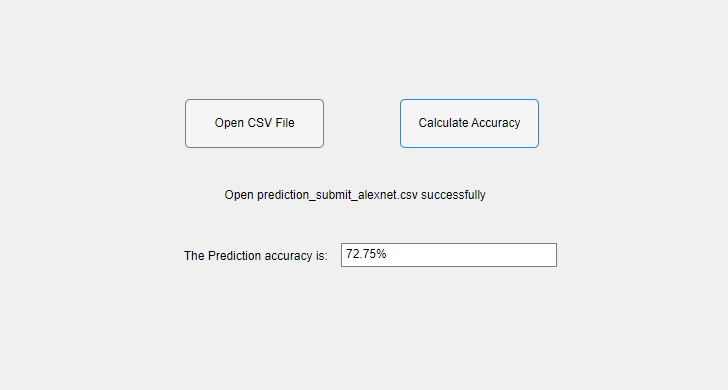

VGG-16

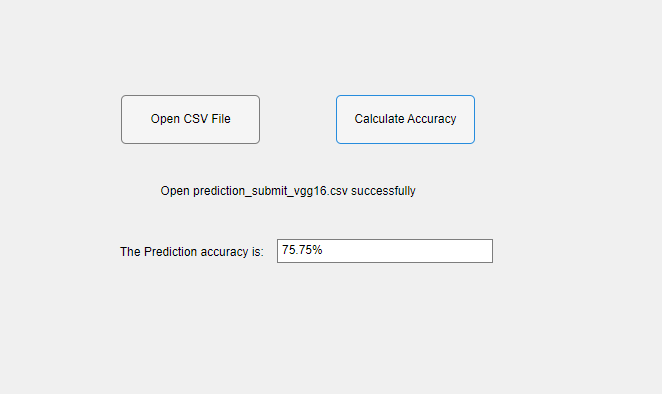

ResNet

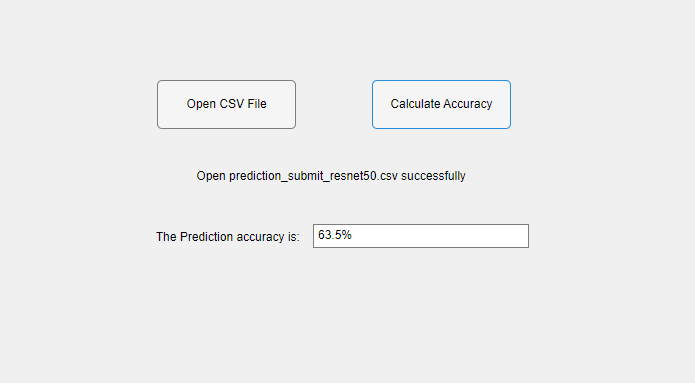

DenseNet

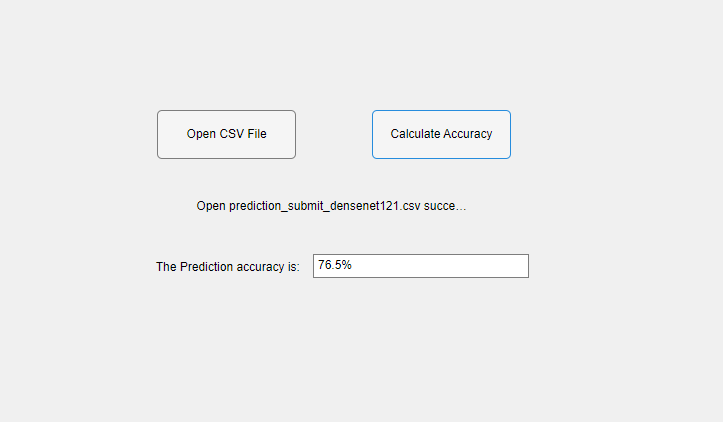

inception

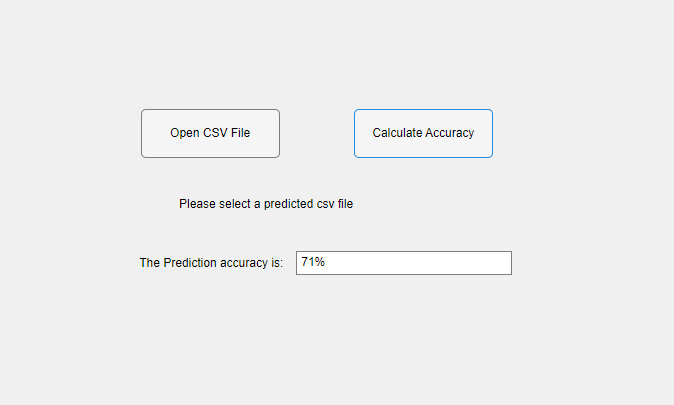

VIT

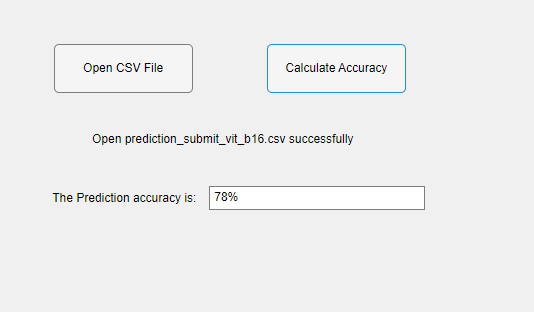

自己最新创建

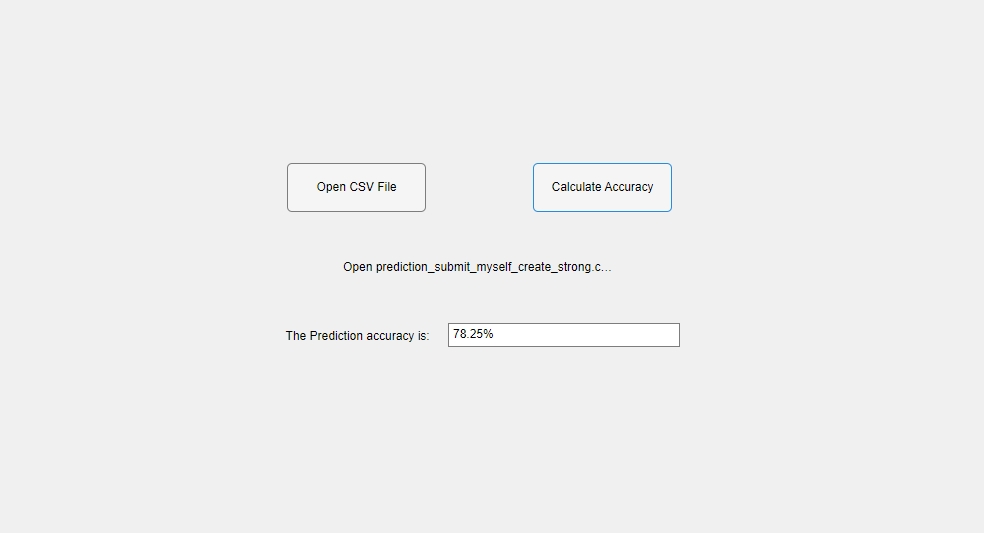

# 4. Compare results with [RVT paper](https://www.nature.com/articles/s41598-023-50063-x). Requirement: performance is better than 75%

# 5. Write a four-page paper report using the shared LaTex template. Upload your paper to ResearchGate or Arxiv, and put your paper link and GitHub weight link here.

报告：

https://www.researchgate.net/publication/405253244_A_Course_Project_Report_on_Three-Class_Dog_Heart_X-ray_Image_Classification

项目文件：

https://github.com/Xinn-hub/Dog-Heart-X-ray-Image-Classification

# 6. Grading rubric

(1). Code ------- 20 points (you also need to upload your final model as a pt file)

(2). Grammer ---- 20 points

(3). Introduction & related work --- 10 points


(4). Method  ---- 20 points

(5). Results ---- 20 points

     > = 75% -->10 points
     < 65 % -->0 points
     >= 65 % & < 75% -->  2 point/percent
     

(6). Discussion - 10 points